# 张量与自动求导
学习 torch.Tensor 的创建、形状变换、广播机制，理解 requires_grad、backward()、grad 三者关系。手写一个一元线性回归，用 loss.backward() 手动更新参数，不调用 optimizer，体会自动微分的本质。

Epoch [50/1000], Loss: 1.2761, w: 2.322, b: 0.929
Epoch [100/1000], Loss: 0.8718, w: 2.256, b: 1.370
Epoch [150/1000], Loss: 0.6260, w: 2.204, b: 1.715
Epoch [200/1000], Loss: 0.4766, w: 2.164, b: 1.983
Epoch [250/1000], Loss: 0.3858, w: 2.132, b: 2.193
Epoch [300/1000], Loss: 0.3306, w: 2.108, b: 2.356
Epoch [350/1000], Loss: 0.2970, w: 2.088, b: 2.483
Epoch [400/1000], Loss: 0.2766, w: 2.074, b: 2.583
Epoch [450/1000], Loss: 0.2642, w: 2.062, b: 2.660
Epoch [500/1000], Loss: 0.2566, w: 2.053, b: 2.721
Epoch [550/1000], Loss: 0.2520, w: 2.046, b: 2.768
Epoch [600/1000], Loss: 0.2492, w: 2.040, b: 2.804
Epoch [650/1000], Loss: 0.2475, w: 2.036, b: 2.833
Epoch [700/1000], Loss: 0.2465, w: 2.033, b: 2.855
Epoch [750/1000], Loss: 0.2459, w: 2.030, b: 2.873
Epoch [800/1000], Loss: 0.2455, w: 2.028, b: 2.886
Epoch [850/1000], Loss: 0.2453, w: 2.026, b: 2.897
Epoch [900/1000], Loss: 0.2451, w: 2.025, b: 2.905
Epoch [950/1000], Loss: 0.2450, w: 2.024, b: 2.911
Epoch [1000/1000], Loss: 0.2450,

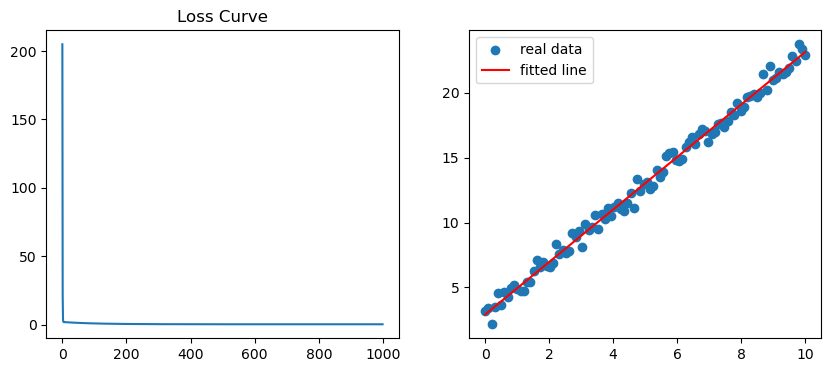

In [5]:
import torch
import matplotlib.pyplot as plt

# ===================== 1. 准备模拟数据 =====================
# 真实公式：y = 2x + 3（我们要让模型拟合出w≈2，b≈3）
x = torch.linspace(0, 10, 100)  # 0到10的100个点
y_true = 2 * x + 3 + torch.randn(x.shape) * 0.5  # 加小噪声

# ===================== 2. 初始化参数（开启梯度追踪） =====================
w = torch.tensor(0.0, requires_grad=True)  # 初始权重
b = torch.tensor(0.0, requires_grad=True)  # 初始偏置
lr = 0.01  # 学习率（手动更新的步长）
epochs = 1000  # 迭代次数

# ===================== 3. 训练循环（核心！） =====================
loss_list = []
for epoch in range(epochs):
    # 1. 前向传播：计算预测值
    y_pred = w * x + b

    # 2. 计算损失：均方误差 MSE
    loss = torch.mean((y_pred - y_true) ** 2)
    loss_list.append(loss.item())

    # 3. 反向传播：自动计算w和b的梯度
    loss.backward()

    # 4. 手动更新参数（核心！禁止计算梯度，纯数值操作）
    with torch.no_grad():  # 关闭计算图追踪
        w -= lr * w.grad   # w = w - 学习率×梯度
        b -= lr * b.grad

    # 5. 梯度清零！！！（必须做，否则梯度累加导致训练失败）
    w.grad.zero_()
    b.grad.zero_()

    # 打印训练过程
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, w: {w.item():.3f}, b: {b.item():.3f}")

# ===================== 4. 结果可视化 =====================
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(loss_list)
plt.title("Loss Curve")
plt.subplot(122)
plt.scatter(x, y_true, label="real data")
plt.plot(x.detach().numpy(), (w*x + b).detach().numpy(), "r-", label="fitted line")
plt.legend()
plt.show()